Estimating Monte Carlo correction gamma (this may take a little time)...
Estimated gamma: 0.064016


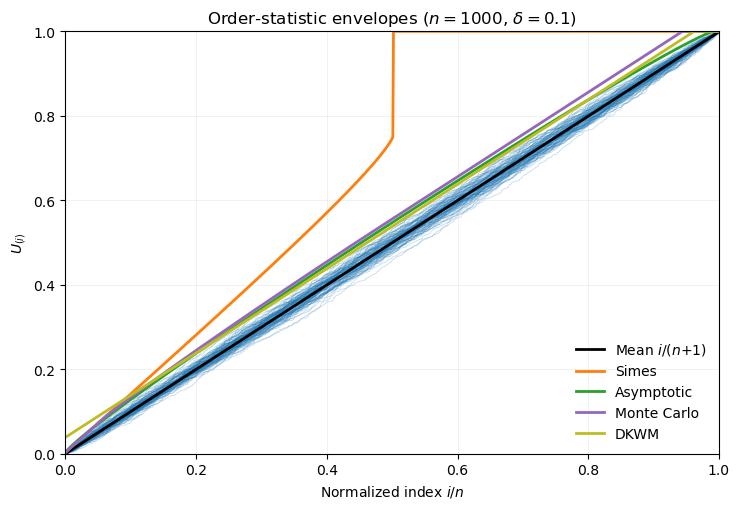

In [1]:
# replicate_figure3_using_utils.py
# Requires: utils_calib.py in the same directory.
# Outputs: figure3_replication.png

import numpy as np
import matplotlib.pyplot as plt

from utils_calib import (
    compute_aseq,          # for SIMES envelope
    compute_cn,            # for ASYMPTOTIC envelope
    compute_hybrid_bound,  # for MONTE CARLO envelope (hybrid)
    estimate_fs_correction # to calibrate the MC envelope's gamma
)

def main(n=1000, J=100, delta=0.10, k_simes=None, seed=123):
    """
    n: number of uniforms (order stats length)
    J: number of sample paths shown
    delta: 1 - coverage level for envelopes
    k_simes: Simes parameter (defaults to n//2, as in the paper)
    """
    if k_simes is None:
        k_simes = n // 2

    rng = np.random.default_rng(seed)

    # x-axis: normalized index i/n
    i = np.arange(1, n + 1)
    x = i / n

    # Theoretical mean of order stats E[U_(i)] = i/(n + 1)
    order_mean = i / (n + 1)

    # ---------- Envelopes ----------
    # 1) SIMES envelope: b_simes = 1 - aseq[::-1]
    aseq_simes = compute_aseq(n, k_simes, delta)          # length n
    b_simes = 1.0 - aseq_simes[::-1]

    # 2) ASYMPTOTIC envelope: b_asym = min(1, i/n + c_n * sqrt(i(n-i)) / (n * sqrt(n)))
    c_n = compute_cn(delta, n)
    b_asym = i / n + c_n * np.sqrt(i * (n - i)) / (n * np.sqrt(n))
    b_asym = np.minimum(1.0, b_asym)

    # 3) MONTE CARLO envelope (hybrid):
    #    First estimate gamma so that crossing probability ~ delta,
    #    then use compute_hybrid_bound(delta, n, gamma).
    print("Estimating Monte Carlo correction gamma (this may take a little time)...")
    gamma = estimate_fs_correction(delta, n)
    print(f"Estimated gamma: {gamma:.6f}")
    b_mc = compute_hybrid_bound(delta, n, gamma)

    # 4) DKWM envelope (Massart-tight):
    #    sup_t |F_n(t)-t| <= eps with prob >= 1 - delta, where eps = sqrt(log(2/delta)/(2n))
    #    Map to an upper envelope on U_(i): ~ i/(n+1) + eps (clipped to [0,1]).
    eps = np.sqrt(np.log(2.0 / delta) / (2.0 * n))
    b_dkwm = np.minimum(order_mean + eps, 1.0)

    # ---------- Sample paths of order statistics ----------
    paths = np.sort(rng.random((J, n)), axis=1)

    # ---------- Plot ----------
    fig, ax = plt.subplots(figsize=(7.5, 5.2))

    # Sample paths (light blue)
    for j in range(J):
        ax.plot(x, paths[j], lw=0.6, alpha=0.25, color="#1f77b4")

    # Theoretical mean (black)
    ax.plot(x, order_mean, lw=2.0, color="black", label=r"Mean $i/(n{+}1)$")

    # Envelopes
    ax.plot(x, b_simes, lw=2.0, label="Simes", color="#ff7f0e")
    ax.plot(x, b_asym,  lw=2.0, label="Asymptotic", color="#2ca02c")
    ax.plot(x, b_mc,    lw=2.0, label="Monte Carlo", color="#9467bd")
    ax.plot(x, b_dkwm,  lw=2.0, label="DKWM", color="#bcbd22")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(r"Normalized index $i/n$")
    ax.set_ylabel(r"$U_{(i)}$")
    ax.set_title(rf"Order-statistic envelopes ($n={n}$, $\delta={delta}$)")
    ax.legend(loc="lower right", frameon=False)
    ax.grid(True, lw=0.4, alpha=0.3)

    plt.tight_layout()
    plt.savefig("figure3_replication.png", dpi=200)
    # plt.show()

if __name__ == "__main__":
    main()


Estimating gamma for MC hybrid...
  gamma = 0.099998


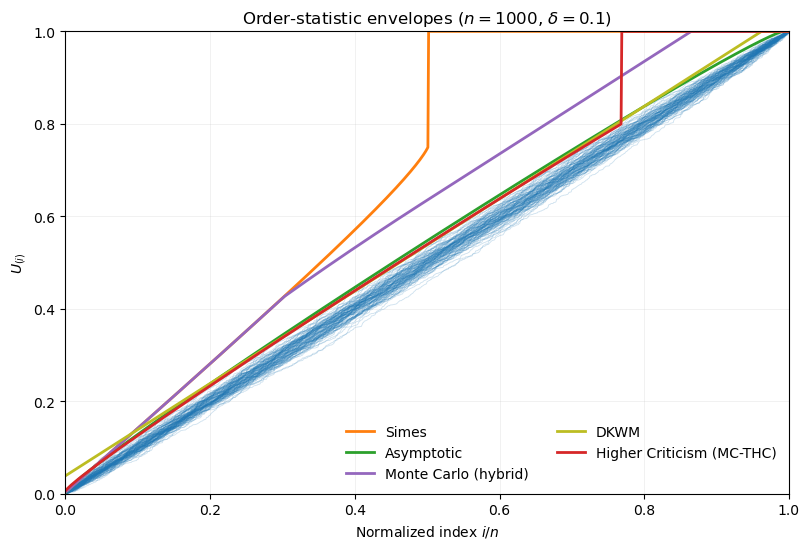

In [36]:
# replicate_figure3_with_HC_fixed.py
# Plots order-statistic envelopes for Unif[0,1] with:
#   Simes, Asymptotic, Monte Carlo (hybrid), DKWM, and Higher Criticism (via your ECDF code).
# Uses: utils_calib.py, ecdf_upper_bound.py

import numpy as np
import matplotlib.pyplot as plt

from utils_calib import (
    compute_aseq,          # Simes a-sequence
    compute_cn,            # asymptotic coefficient c_n(delta, n)
    estimate_fs_correction,# gamma calibration for MC hybrid
    compute_hybrid_bound   # MC hybrid envelope on order stats
)
from ecdf_upper_bound import uniform_ecdf_upper_bound  # returns an ECDF UPPER envelope callable

# ---------- Helpers ----------

def invert_ecdf_lower_envelope_to_order_upper(f_lower, n, grid_size=20001):
    """
    Given f_lower: [0,1] -> [0,1], a LOWER envelope for the ECDF (i.e., F_hat(t) >= f_lower(t) for all t),
    return an order-statistic UPPER envelope b[1..n] such that U_(i) <= b_i for all i.

    We compute b_i = inf{x in [0,1] : f_lower(x) >= i/n} on a fine grid.
    """
    xs = np.linspace(0.0, 1.0, grid_size)
    vals = f_lower(xs)  # expected nondecreasing w.r.t xs
    vals = np.minimum(np.maximum(vals, 0.0), 1.0)

    b = np.empty(n, dtype=float)
    target = np.arange(1, n + 1) / n

    # First index where f_lower(xs) >= target
    idx = np.searchsorted(vals, target, side="left")
    idx = np.clip(idx, 0, grid_size - 1)
    b[:] = xs[idx]

    # enforce monotonicity and clip
    b = np.maximum.accumulate(np.clip(b, 0.0, 1.0))
    return b

def ecdf_lower_from_upper(f_upper):
    """
    Mirror an ECDF UPPER envelope U(t) into a LOWER envelope:
        L(t) = 1 - U(1 - t).
    This guarantees  F_hat(t) >= L(t)  whenever  F_hat(t) <= U(t).
    """
    def f_lower(t):
        t_arr = np.asarray(t)
        return np.maximum(0.0, 1.0 - f_upper(1.0 - t_arr))
    return f_lower

# ---------- Main ----------

def main(n=1000, J=100, delta=0.10, seed=123,
         hc_method="MC-THC", hc_beta=0.5, hc_lower=0.01, hc_upper=0.99,
         hc_N=3000, hc_randomize=False, grid_size=20001, k_simes=None):

    if k_simes is None:
        k_simes = n // 2  # as in the paper

    rng = np.random.default_rng(seed)

    # x-axis (normalized index) and mean curve
    i = np.arange(1, n + 1)
    x = i / n
    order_mean = i / (n + 1)

    # ----- 1) Simes envelope (via a-sequence) -----
    aseq_simes = compute_aseq(n, k_simes, delta)   # length n, nondecreasing
    b_simes = 1.0 - aseq_simes[::-1]               # order-stat upper curve

    # ----- 2) Asymptotic envelope -----
    c_n = compute_cn(delta, n)
    b_asym = i / n + c_n * np.sqrt(i * (n - i)) / (n * np.sqrt(n))
    b_asym = np.minimum(1.0, b_asym)

    # ----- 3) Monte Carlo (hybrid) envelope -----
    print("Estimating gamma for MC hybrid...")
    gamma = estimate_fs_correction(delta, n)
    print(f"  gamma = {gamma:.6f}")
    b_mc = compute_hybrid_bound(delta, n, gamma)   # order-stat upper curve

    # ----- 4) DKWM envelope (Massart-tight) -----
    eps = np.sqrt(np.log(2.0 / delta) / (2.0 * n))
    b_dkwm = np.minimum(order_mean + eps, 1.0)

    # ----- 5) Higher-Criticism envelope via your ECDF routine -----
    # Build ECDF UPPER envelope using your MC-HC/THC/KS/BJ method:
    # uniform_ecdf_upper_bound(...) -> callable U(t) with P(F_hat(t) <= U(t) ∀t) ≥ 1-δ
    f_ecdf_upper = uniform_ecdf_upper_bound(
        n=n, m=n, N=hc_N, delta=delta, beta=hc_beta,
        lower=hc_lower, upper=hc_upper,
        setting='iid', seed=seed, method=hc_method, randomize=hc_randomize
    )

    # Mirror to obtain a LOWER ECDF envelope, then invert to order-stat upper curve
    f_ecdf_lower = ecdf_lower_from_upper(f_ecdf_upper)
    b_hc = invert_ecdf_lower_envelope_to_order_upper(f_ecdf_lower, n=n, grid_size=grid_size)

    # ----- Sample paths of order statistics (blue, faint) -----
    paths = np.sort(rng.random((J, n)), axis=1)

    # ----- Plot -----
    fig, ax = plt.subplots(figsize=(8.2, 5.6))

    # Sample paths
    for j in range(J):
        ax.plot(x, paths[j], lw=0.6, alpha=0.22, color="#1f77b4")

    # Mean and envelopes
    #ax.plot(x, order_mean, lw=2.0, color="black", label=r"Mean $i/(n{+}1)$")
    ax.plot(x, b_simes,  lw=2.0, color="#ff7f0e", label="Simes")
    ax.plot(x, b_asym,   lw=2.0, color="#2ca02c", label="Asymptotic")
    ax.plot(x, b_mc,     lw=2.0, color="#9467bd", label="Monte Carlo (hybrid)")
    ax.plot(x, b_dkwm,   lw=2.0, color="#bcbd22", label="DKWM")
    ax.plot(x, b_hc,     lw=2.0, color="#d62728", label=f"Higher Criticism ({hc_method})")

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(r"Normalized index $i/n$")
    ax.set_ylabel(r"$U_{(i)}$")
    ax.set_title(rf"Order-statistic envelopes ($n={n}$, $\delta={delta}$)")
    ax.legend(loc="lower right", frameon=False, ncol=2)
    ax.grid(True, lw=0.4, alpha=0.3)

    plt.tight_layout()
    plt.savefig("figure3_with_HC_fixed.png", dpi=220)
    # plt.show()

if __name__ == "__main__":
    # Choose one of: 'MC-HC', 'MC-THC', 'MC-KS', 'MC-BJ'
    main(n=1000, J=100, delta=0.10, seed=123,
         hc_method="MC-THC", hc_beta=0.5, hc_lower=0.2, hc_upper=0.999,
         hc_N=3000, hc_randomize=False, grid_size=20001)


Estimating gamma for MC hybrid...
  gamma = 0.086700


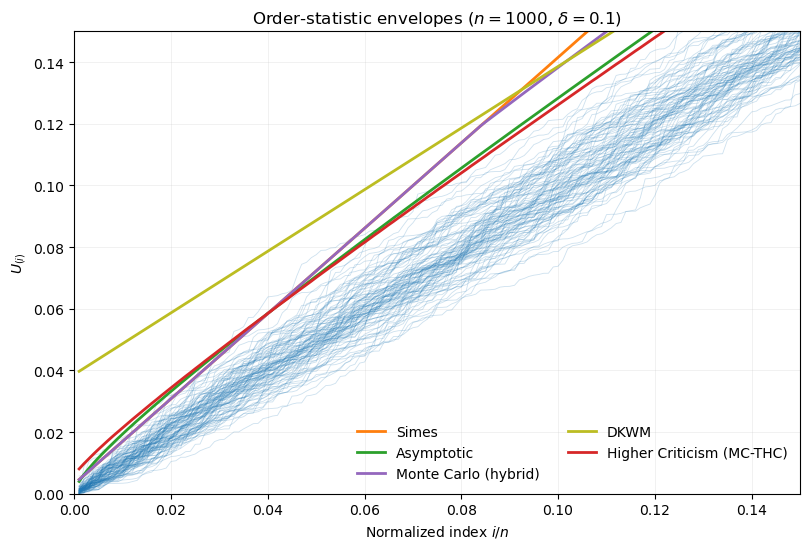

In [33]:
# replicate_figure3_with_HC_fixed.py
# Plots order-statistic envelopes for Unif[0,1] with:
#   Simes, Asymptotic, Monte Carlo (hybrid), DKWM, and Higher Criticism (via your ECDF code).
# Uses: utils_calib.py, ecdf_upper_bound.py

import numpy as np
import matplotlib.pyplot as plt

from utils_calib import (
    compute_aseq,          # Simes a-sequence
    compute_cn,            # asymptotic coefficient c_n(delta, n)
    estimate_fs_correction,# gamma calibration for MC hybrid
    compute_hybrid_bound   # MC hybrid envelope on order stats
)
from ecdf_upper_bound import uniform_ecdf_upper_bound  # returns an ECDF UPPER envelope callable

# ---------- Helpers ----------

def invert_ecdf_lower_envelope_to_order_upper(f_lower, n, grid_size=20001):
    """
    Given f_lower: [0,1] -> [0,1], a LOWER envelope for the ECDF (i.e., F_hat(t) >= f_lower(t) for all t),
    return an order-statistic UPPER envelope b[1..n] such that U_(i) <= b_i for all i.

    We compute b_i = inf{x in [0,1] : f_lower(x) >= i/n} on a fine grid.
    """
    xs = np.linspace(0.0, 1.0, grid_size)
    vals = f_lower(xs)  # expected nondecreasing w.r.t xs
    vals = np.minimum(np.maximum(vals, 0.0), 1.0)

    b = np.empty(n, dtype=float)
    target = np.arange(1, n + 1) / n

    # First index where f_lower(xs) >= target
    idx = np.searchsorted(vals, target, side="left")
    idx = np.clip(idx, 0, grid_size - 1)
    b[:] = xs[idx]

    # enforce monotonicity and clip
    b = np.maximum.accumulate(np.clip(b, 0.0, 1.0))
    return b

def ecdf_lower_from_upper(f_upper):
    """
    Mirror an ECDF UPPER envelope U(t) into a LOWER envelope:
        L(t) = 1 - U(1 - t).
    This guarantees  F_hat(t) >= L(t)  whenever  F_hat(t) <= U(t).
    """
    def f_lower(t):
        t_arr = np.asarray(t)
        return np.maximum(0.0, 1.0 - f_upper(1.0 - t_arr))
    return f_lower

# ---------- Main ----------

def main(n=1000, J=100, delta=0.10, seed=123,
         hc_method="MC-THC", hc_beta=0.5, hc_lower=0.01, hc_upper=0.99,
         hc_N=3000, hc_randomize=False, grid_size=20001, k_simes=None):

    if k_simes is None:
        k_simes = n // 2  # as in the paper

    rng = np.random.default_rng(seed)

    # x-axis (normalized index) and mean curve
    i = np.arange(1, n + 1)
    x = i / n
    order_mean = i / (n + 1)

    # ----- 1) Simes envelope (via a-sequence) -----
    aseq_simes = compute_aseq(n, k_simes, delta)   # length n, nondecreasing
    b_simes = 1.0 - aseq_simes[::-1]               # order-stat upper curve

    # ----- 2) Asymptotic envelope -----
    c_n = compute_cn(delta, n)
    b_asym = i / n + c_n * np.sqrt(i * (n - i)) / (n * np.sqrt(n))
    b_asym = np.minimum(1.0, b_asym)

    # ----- 3) Monte Carlo (hybrid) envelope -----
    print("Estimating gamma for MC hybrid...")
    gamma = estimate_fs_correction(delta, n)
    print(f"  gamma = {gamma:.6f}")
    b_mc = compute_hybrid_bound(delta, n, gamma)   # order-stat upper curve

    # ----- 4) DKWM envelope (Massart-tight) -----
    eps = np.sqrt(np.log(2.0 / delta) / (2.0 * n))
    b_dkwm = np.minimum(order_mean + eps, 1.0)

    # ----- 5) Higher-Criticism envelope via your ECDF routine -----
    # Build ECDF UPPER envelope using your MC-HC/THC/KS/BJ method:
    # uniform_ecdf_upper_bound(...) -> callable U(t) with P(F_hat(t) <= U(t) ∀t) ≥ 1-δ
    f_ecdf_upper = uniform_ecdf_upper_bound(
        n=n, m=n, N=hc_N, delta=delta, beta=hc_beta,
        lower=hc_lower, upper=hc_upper,
        setting='iid', seed=seed, method=hc_method, randomize=hc_randomize
    )

    # Mirror to obtain a LOWER ECDF envelope, then invert to order-stat upper curve
    f_ecdf_lower = ecdf_lower_from_upper(f_ecdf_upper)
    b_hc = invert_ecdf_lower_envelope_to_order_upper(f_ecdf_lower, n=n, grid_size=grid_size)

    # ----- Sample paths of order statistics (blue, faint) -----
    paths = np.sort(rng.random((J, n)), axis=1)

    # ----- Plot -----
    fig, ax = plt.subplots(figsize=(8.2, 5.6))

    # Sample paths
    for j in range(J):
        ax.plot(x, paths[j], lw=0.6, alpha=0.22, color="#1f77b4")

    # Mean and envelopes
    #ax.plot(x, order_mean, lw=2.0, color="black", label=r"Mean $i/(n{+}1)$")
    ax.plot(x, b_simes,  lw=2.0, color="#ff7f0e", label="Simes")
    ax.plot(x, b_asym,   lw=2.0, color="#2ca02c", label="Asymptotic")
    ax.plot(x, b_mc,     lw=2.0, color="#9467bd", label="Monte Carlo (hybrid)")
    ax.plot(x, b_dkwm,   lw=2.0, color="#bcbd22", label="DKWM")
    ax.plot(x, b_hc,     lw=2.0, color="#d62728", label=f"Higher Criticism ({hc_method})")

    ax.set_xlim(0, 0.15)
    ax.set_ylim(0, 0.15)
    ax.set_xlabel(r"Normalized index $i/n$")
    ax.set_ylabel(r"$U_{(i)}$")
    ax.set_title(rf"Order-statistic envelopes ($n={n}$, $\delta={delta}$)")
    ax.legend(loc="lower right", frameon=False, ncol=2)
    ax.grid(True, lw=0.4, alpha=0.3)

    plt.tight_layout()
    plt.savefig("figure3_with_HC_fixed_zoom.png", dpi=220)
    # plt.show()

if __name__ == "__main__":
    # Choose one of: 'MC-HC', 'MC-THC', 'MC-KS', 'MC-BJ'
    main(n=1000, J=100, delta=0.10, seed=123,
         hc_method="MC-THC", hc_beta=0.5, hc_lower=0.2, hc_upper=0.999,
         hc_N=3000, hc_randomize=False, grid_size=20001)
